# Forward Elimination

**Forward elimination** is a stepwise feature selection technique used in machine learning to identify the most relevant features for building a model. Instead of using all available data columns, which may include redundant or unimportant information, this technique builds the feature set one step at a time to improve model performance.

### The Forward Elimination Technique

The process follows a structured, iterative approach:

1.  **Initial Individual Testing:** Start with an empty set of features and a chosen machine learning model. Each feature in the dataset is tested individually by training the model on it and recording the resulting accuracy or performance score.
2.  **Selecting the Best Starting Feature:** The single feature that produces the highest accuracy is selected as the first permanent feature of the model.
3.  **Iterative Pairing:** The selected feature is then paired with every remaining feature one by one. For example, if "Feature 3" was the best individual performer, the model is then tested on pairs like (Feature 3, Feature 1), (Feature 3, Feature 2), and so on.
4.  **Performance Check:** A new feature is added to the permanent set only if the combined accuracy is higher than the previous step's accuracy. If adding a feature results in lower or stagnant accuracy, that feature is not selected.
5.  **Expansion:** This process repeats for groups of three, four, and more features until the highest possible accuracy is achieved or until adding more features no longer provides significant improvement.

### The Efficient Way: Sequential Feature Selector (SFS)

The most efficient and automated way to handle forward elimination is by using the **`SequentialFeatureSelector`** class from the **`mlxtend`** library. This tool automates the iterative process that would otherwise be very time-consuming to perform manually.

*   **How it Works:** You provide the selector with a machine learning model (an **estimator**, such as Logistic Regression) and the specific number of features (**`k_features`**) you want to find.
*   **Automation:** It starts with an empty set and automatically tests each feature, calculates an **accuracy score**, and selects the best one. It then iteratively adds the next best feature that improves the score the most.
*   **Efficiency:** Instead of manually building and testing every possible combination, the `mlxtend` tool allows you to change the number of features and immediately observe which subset yields the **highest accuracy**.

### Techniques for Efficient Selection

Beyond automation, there are several methods to identify and select important features for the forward elimination process:

*   **Performance Comparison:** A feature is added only if it increases the model's accuracy compared to the previous step. For example, if a single feature gives 75% accuracy and adding a second feature increases it to 85%, that second feature is efficiently selected as "important".
*   **Correlation Method:** You can use a **correlation matrix** to see which features have a strong relationship with the output. Highly correlated features are often the most efficient ones to test first in forward elimination.
*   **Tree-Based Importance:** Using **Random Forest Importance** or **Decision Trees** allows you to rank features by their importance scores before you even begin the elimination process.
*   **Domain Knowledge:** The most efficient human-led way to select features is through **domain expertise**. Understanding the data allows you to immediately remove "unimportant" or redundant columns (such as IDs or irrelevant observations) before starting the algorithmic selection.

By combining **domain knowledge** with automated tools like **`mlxtend`**, you can efficiently narrow down a dataset with many columns (e.g., 115 features) to only the most critical ones required for a high-performing model.

---

# Backward Elimination

**Backward elimination** is a stepwise feature selection technique used to identify the most significant features for a machine learning model by starting with a full set of features and systematically removing the least important ones. This method is particularly useful for building efficient models when you have many columns of data and want to determine which ones are truly necessary for accurate predictions, even if you lack deep domain knowledge about the dataset.

### The Backward Elimination Technique

The process follows a structured, iterative approach that is essentially the reverse of forward elimination:

1.  **Start with All Features:** Unlike forward elimination, which starts with an empty set, backward elimination begins by training the chosen machine learning model using **every available feature** in the dataset.
2.  **Initial Performance Check:** The accuracy or performance score of this "full" model is recorded as the baseline.
3.  **Iterative Removal:** The technique then tests the model by removing one feature at a time. For example, if you start with five features, you would test five different models, each containing a different combination of four features.
4.  **Selecting the Best Subset:** You identify which group of features produces the highest accuracy. If removing a specific feature actually **improves** the model’s accuracy or keeps it stable, that feature is permanently discarded from the set.
5.  **Continuation:** This process repeats—reducing the set to three features, then two, and so on—until removing further features causes a significant drop in model performance. The final remaining features are considered the "best" or most impactful features for the model.

### Efficient Implementation and Automation

To perform backward elimination efficiently without manual iteration, the sources suggest using specialized tools:

*   **Sequential Feature Selector (SFS):** The `mlxtend` library provides a `SequentialFeatureSelector` tool that can automate this entire process. To use it for backward elimination, you simply set the parameter `forward=False`. 
*   **Hyperparameter Control:** When using automated selectors, you can specify the exact number of features (`k_features`) you want the model to eventually reach, allowing the algorithm to find the highest-scoring subset for that specific number.
*   **Model Improvement:** By stripping away unneeded or redundant features through backward elimination, you can reduce **computational power** requirements and help the model train faster while often achieving better accuracy than a model cluttered with "noise".

---

### Efficient Ways to Select Important Features

While manual forward elimination is possible, the sources highlight more efficient ways to handle feature selection automatically and mathematically:

*   **Sequential Feature Selector (SFS):** An efficient way to automate both forward and backward elimination is using the `SequentialFeatureSelector` from the `mlxtend` library. This tool allows you to specify a machine learning model (like Logistic Regression) and the number of features you want to find. By running this selector for different numbers of features (e.g., testing for the best 3 vs. the best 5), you can efficiently identify the smallest subset of features that maintains high accuracy.
*   **Lasso Regularization (L1):** This is a mathematical approach where a penalty is added to the cost function of a model. It is highly efficient because it can shrink the coefficients of unimportant features to exactly zero, effectively performing feature selection during the training process itself.
*   **Tree-Based Importance:** Using algorithms like **Random Forest** or **Decision Trees** is an efficient way to rank features based on how much they contribute to reducing error in the model.
*   **Correlation Analysis:** Before training, you can use a **Correlation Matrix** (often visualised as a heatmap) to see which features have a strong relationship with the target variable. Features with very low correlation can often be efficiently removed early in the process.
*   **Domain Knowledge:** One of the most efficient "human" ways to select features is through domain expertise. Understanding the data's context allows a scientist to immediately identify and remove columns that logically have no impact on the outcome, such as ID numbers or redundant observational data.

In [1]:
# pip install --upgrade pip

In [2]:
# pip install mlxtend

In [3]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
import warnings

warnings.filterwarnings('ignore')

In [4]:
file_path = "diabetes.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mathchi/diabetes-data-set",
  file_path,
)

In [5]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
x = df.iloc[:,:]
y = df.Outcome

In [7]:
df.shape

(768, 9)

In [8]:
Lr = LogisticRegression()

In [9]:
df.shape

(768, 9)

In [10]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
Sf = SequentialFeatureSelector(Lr,k_features=9,forward=True)
Sf.fit(x,y)

,estimator,LogisticRegression()
,k_features,"(9, ...)"
,forward,True
,floating,False
,verbose,0
,scoring,'accuracy'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [12]:
Sf.feature_names

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [13]:
Sf.k_feature_names_

('Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome')

In [14]:
Sf.k_score_

np.float64(1.0)

In [15]:
Sf1 = SequentialFeatureSelector(Lr,k_features=5,forward=True)
Sf1.fit(x,y)

,estimator,LogisticRegression()
,k_features,"(5, ...)"
,forward,True
,floating,False
,verbose,0
,scoring,'accuracy'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [16]:
Sf.k_score_

np.float64(1.0)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train,X_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test,y_pred))

1.0


### Why on Earth does this dataset has a prediction score of 1.0

A **prediction score of 1.0 (100% accuracy)** is rare in real-world machine learning and typically signals **overfitting or data leakage** rather than a perfect model. The sources explain that if a model is trained and evaluated on the same dataset, it simply **memorises relationships** rather than learning patterns that generalise to unseen data. This is comparable to a student who memorises 10 specific exam questions; they will achieve a perfect score on that exact test but fail to handle new, unseen questions.

Another factor contributing to perfect scores is the nature of the data, such as beginner-friendly datasets that are **highly separable** or contain features that correlate too strongly with the target variable. In some cases, a small dataset size—such as 768 rows—allows a model to quickly learn nearly every existing pattern, leading to deceptive results.

To resolve these issues and obtain realistic performance measurements, a proper **train-test split** or cross-validation workflow must be introduced. The sources state that a model should be built using training data, while **testing data must remain completely unseen** until the final evaluation to judge how the system behaves in real-world scenarios. Furthermore, implementing **feature selection** to remove unimportant columns and using **feature scaling** ensures the model focuses on the most relevant information without being dominated by large, irrelevant values. Finally, **regularisation techniques** like Lasso (L1) or Ridge (L2) can be applied to reduce overfitting by penalising overly complex models.

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

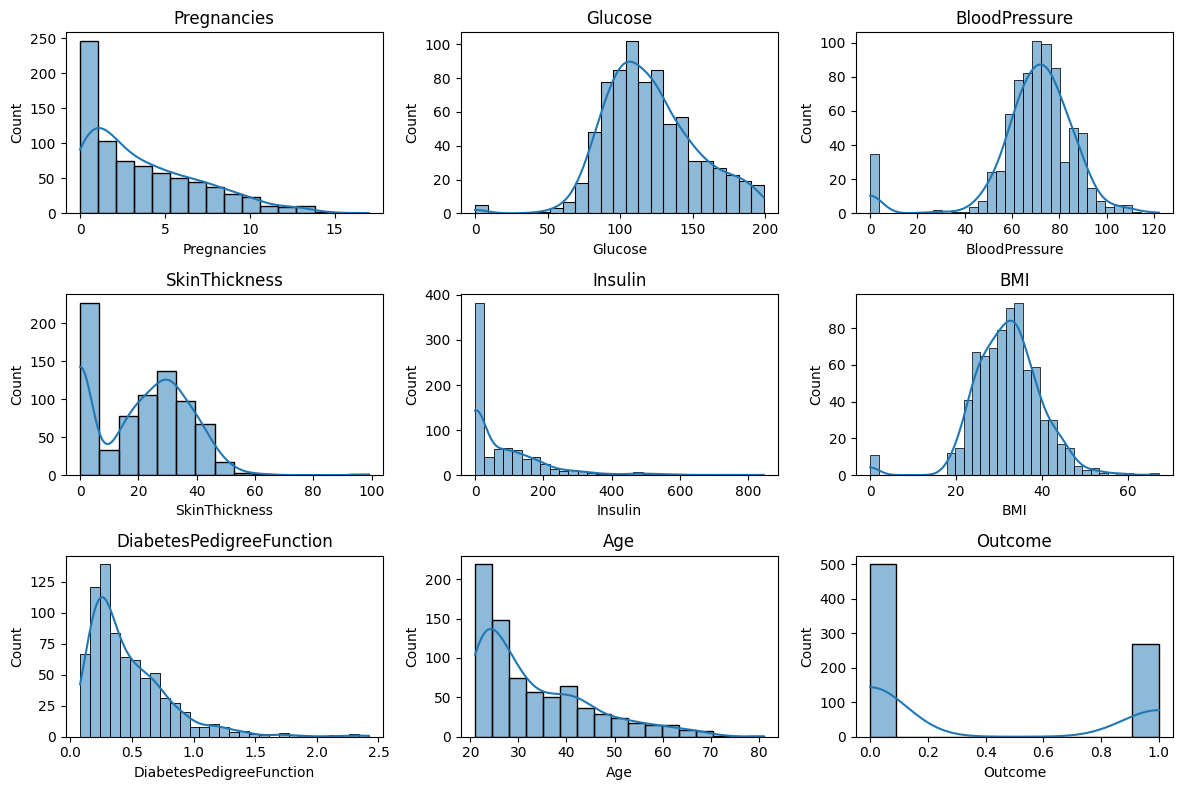

In [19]:
plt.figure(figsize=(12,8))
cols = df.columns
for i, col in enumerate(cols, 1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [20]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')